# **04. CLTV Using Probabilistic Models**

## **Introduction**

We aim to compute __Customer Lifetime Value (CLTV)__ using a __probabilistic modeling approach__. Specifically, we will apply the __BG/NBD__ and __Pareto/NBD__ models to estimate customer purchasing behavior over time. In addition, the __Gamma-Gamma model__  will be used to evaluate the expected monetary value of transactions. Together, these models allow us to estimate the average profit that can be generated from each customer, providing a robust framework for understanding long-term customer profitability.

### **Goal**

- **Estimate CLTV**: Quantify the long-term value each customer contributes to the business.

- **Model purchase frequency**: Use BG/NBD and Pareto/NBD models to capture how often customers are likely to buy and how long they remain active.

- **Assess transaction value**: Apply the Gamma-Gamma model to estimate the average profit we can earn for each customer.



### **1. Requirements**

In [75]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable
from pathlib import Path
from IPython.display import display
from IPython.display import Markdown


In [76]:
# display setting
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

import warnings
warnings.simplefilter("ignore", category=FutureWarning)

# Display markdown formatted output like bold, italic bold etc.'''
def display_md(string):
    display(Markdown(string))

    

In [77]:
# Define paths to read files
parent_path = Path.cwd().parent
data_path = parent_path.joinpath('data', 'processed')

files = []
for file in data_path.rglob('*.csv'):
    files.append(file)
    print(files.index(file), ' ', file.name)

0   kmeans_df.csv
1   processed_data.csv


In [78]:
display_md("**Loading Raw Dataset...**")
try:
    processed_df = pd.read_csv(files[0])
    
    # standardize the column names
    processed_df.columns = processed_df.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")

    # take a copy of original dataframe
    customer_df = processed_df.copy()
    
    # Conversion of 'Dt_Customer' into datetime
    customer_df['Dt_Customer'] = pd.to_datetime(customer_df['Dt_Customer'], format='%Y-%m-%d')#, dayfirst=True)
    display_md(f"**Dataset Shape : {customer_df.shape}**")
    display_md(f"**Number of duplicate rows in dataset : {customer_df.duplicated().sum()}**")
    
except Exception as e:
    print(f"Error raised while loading file : {e}")



**Loading Raw Dataset...**

**Dataset Shape : (2214, 40)**

**Number of duplicate rows in dataset : 0**

The dataset has been thoroughly cleaned and preprocessed, making it ready for the application of probabilistic modeling techniques.

## **2. Probabilistic Modeling Techniques**

Will use these two approaches :

- **BG/NBD** : BG/NBD model (Beta-Geometric/Negative Binomial Distribution) is designed to predict how often customers will make repeat purchases and when they might stop buying altogether. It assumes that each customer has a certain probability of 'dropping out/inactive/churn', and that probability varies across the customer base.

- **Pareto/NBD** : Pareto/NBD model works in a similar way but uses a Pareto distribution to model dropout behavior. It is often considered more flexible and can provide slightly different insights into customer retention compared to BG/NBD.

- **Gamma-Gamma Model** : Gamma-Gamma model complements these by focusing on the monetary side. It estimates the average transaction value for each customer, assuming that while customers differ in how much they spend, their spending habits remain consistent over time.

In [79]:
import lifetimes
from lifetimes import BetaGeoFitter
from lifetimes.plotting import plot_frequency_recency_matrix
from lifetimes.plotting import plot_probability_alive_matrix
from lifetimes.plotting import plot_period_transactions
from lifetimes.utils import calibration_and_holdout_data
from lifetimes.plotting import *
from sklearn.metrics import mean_squared_error
from math import sqrt
from lifetimes import ParetoNBDFitter
from lifetimes.plotting import plot_history_alive
import pickle
from lifetimes import ModifiedBetaGeoFitter
from lifetimes import GammaGammaFitter


In [80]:
# Compute tenure in days for model requirements
customer_df['T'] = (
    (
        customer_df['Dt_Customer'].max() - customer_df['Dt_Customer']
    ).dt.days
    
)
customer_df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Is_parent,Children,Day,Month,Quarter,Year,Monetary,Frequency,Tenure,Cluster,T
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,58,0,0,4,9,3,2012,1617,22,28,1,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,61,1,2,8,3,1,2014,27,4,9,0,113
2,4141,1965,Graduation,Partner,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,50,0,0,21,8,3,2013,776,20,16,2,312
3,6182,1984,Graduation,Partner,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,31,1,1,10,2,1,2014,53,6,10,0,139
4,5324,1981,PhD,Partner,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,34,1,1,19,1,1,2014,422,14,11,2,161


In [81]:
rfm_df = customer_df[['ID', 'Recency', 'Frequency', 'Monetary', 'T']].copy()
rfm_df.head()

,ID,Recency,Frequency,Monetary,T
0,5524,58,22,1617,663
1,2174,38,4,27,113
2,4141,26,20,776,312
3,6182,26,6,53,139
4,5324,94,14,422,161


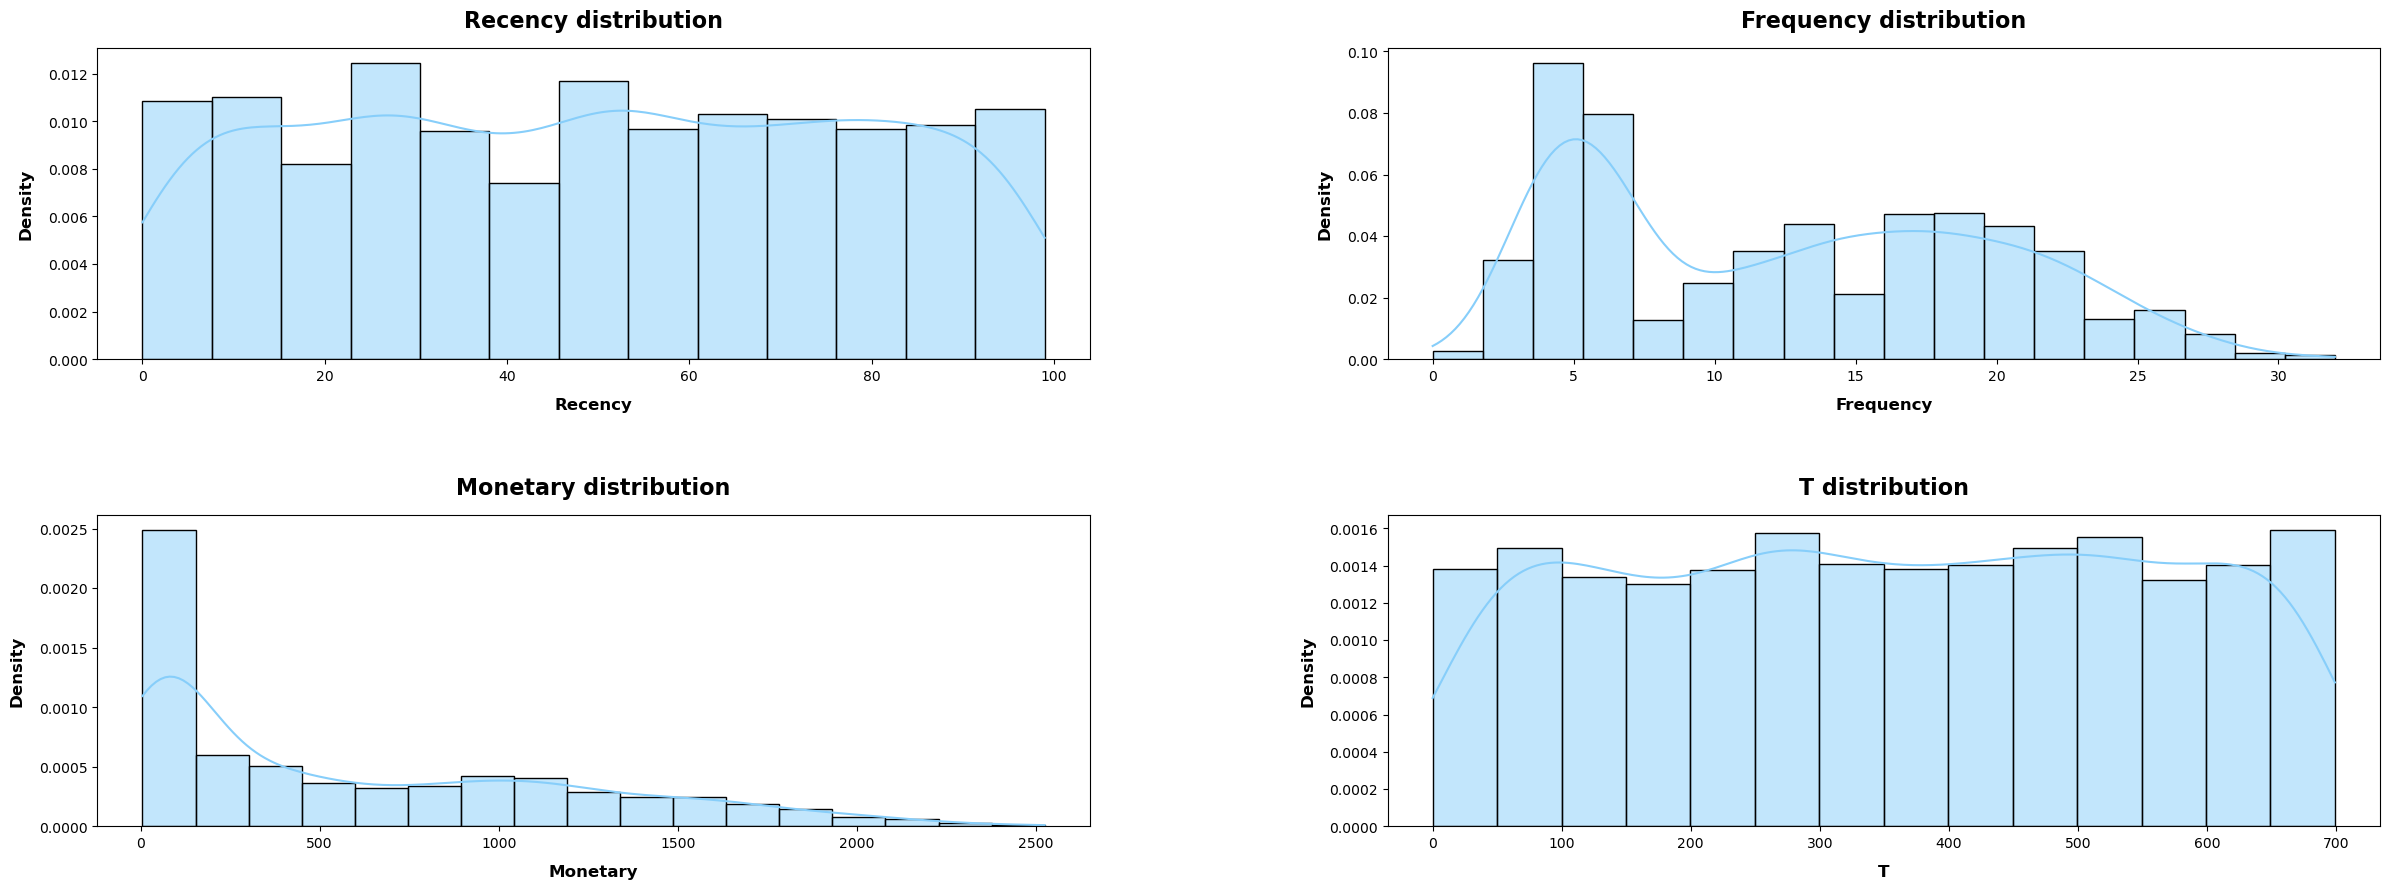

In [82]:
# plotting distriution of RFM-T features
fig, ax = plt.subplots(2, 2, figsize=(24, 9))
ax=ax.flatten()
for i, col in enumerate(['Recency', 'Frequency', 'Monetary', 'T']):
    sns.histplot(data=customer_df, x=col, stat='density', kde=True, color='lightskyblue', ax=ax[i])
    ax[i].set_title(f"{col} distribution", fontsize=16, fontweight='bold', y=1.04)
    ax[i].set_xlabel(f"{col}", fontsize=12, fontweight='bold', labelpad=10)
    ax[i].set_ylabel('Density', fontsize=12, fontweight='bold', labelpad=10)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.5)
plt.show()


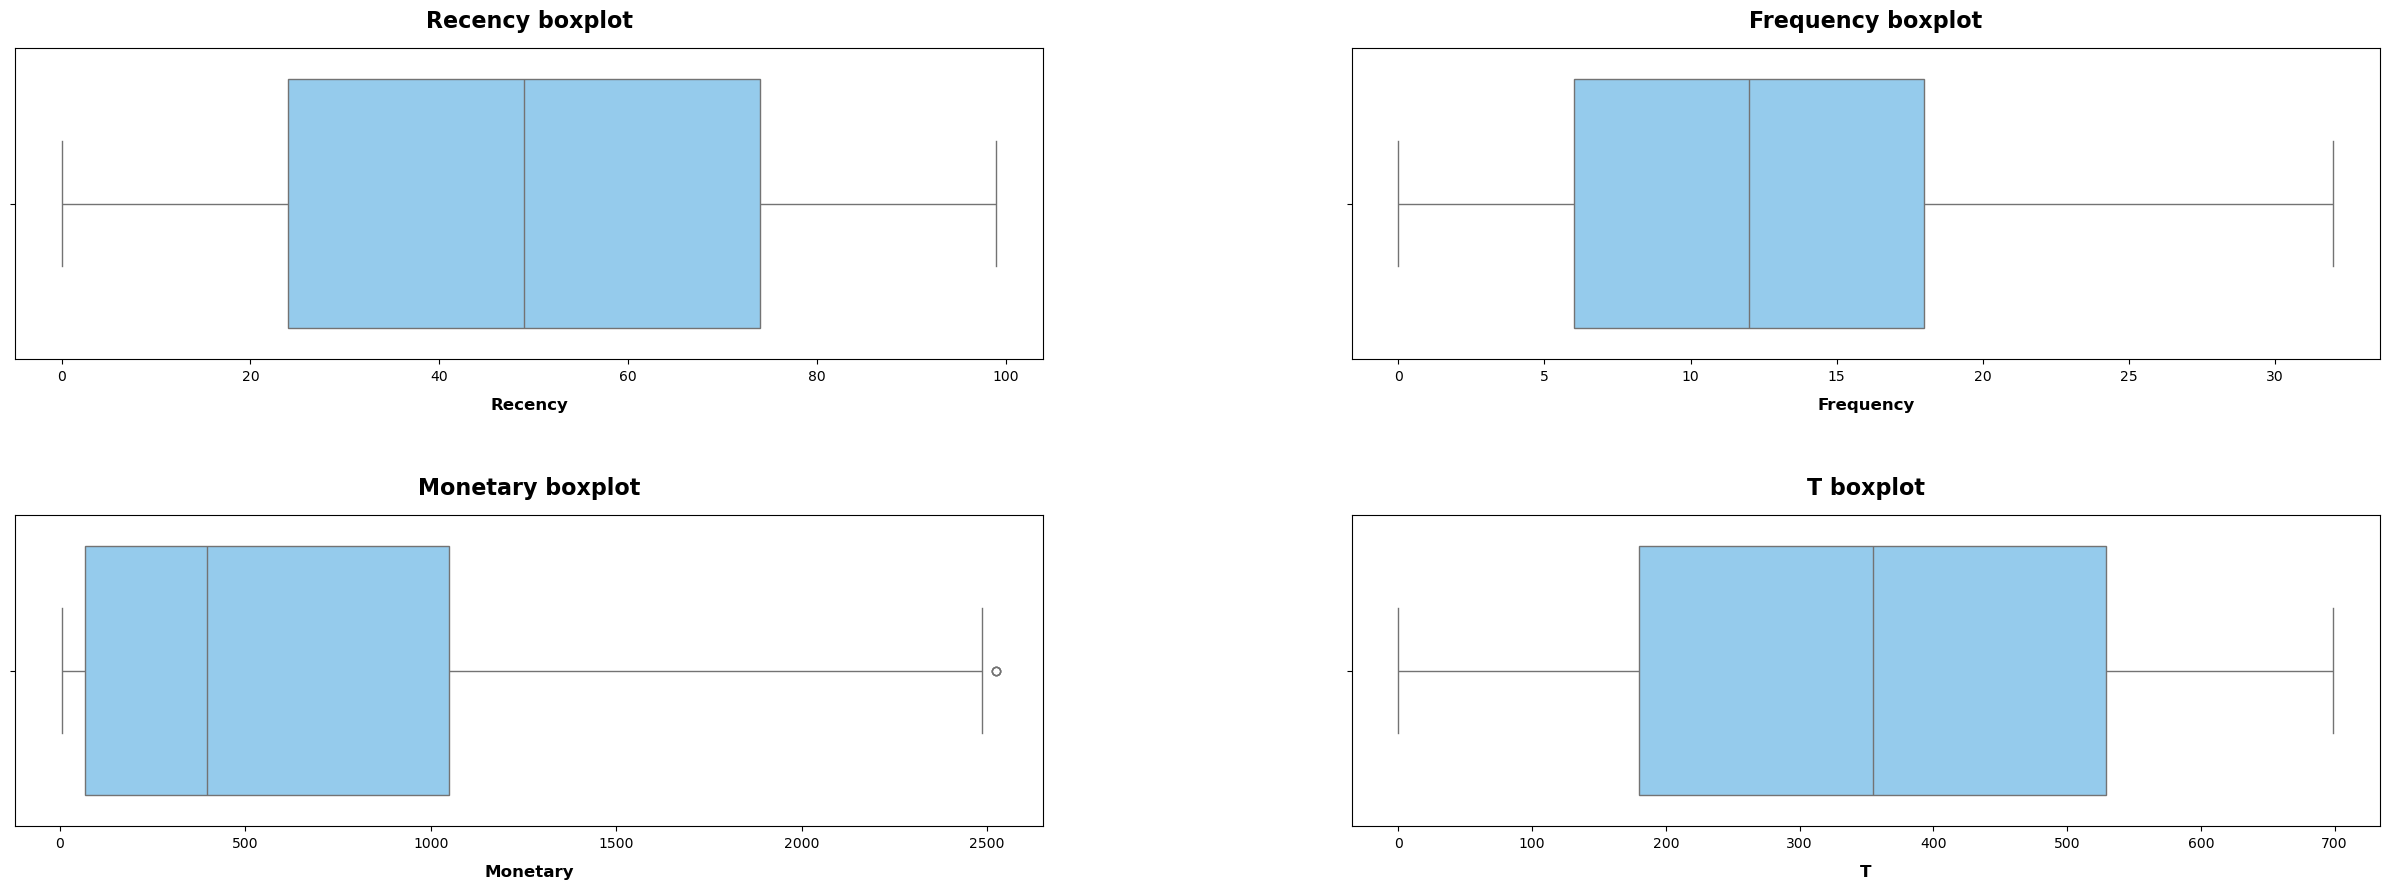

In [83]:
# plotting distriution of RFM-T features
fig, ax = plt.subplots(2, 2, figsize=(24, 9))
ax=ax.flatten()
for i, col in enumerate(['Recency', 'Frequency', 'Monetary', 'T']):
    sns.boxplot(data=customer_df, x=col, color='lightskyblue', ax=ax[i])
    ax[i].set_title(f"{col} boxplot", fontsize=16, fontweight='bold', y=1.04)
    ax[i].set_xlabel(f"{col}", fontsize=12, fontweight='bold', labelpad=10)
    #ax[i].set_ylabel('Density', fontsize=12, fontweight='bold', labelpad=10)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.5)
plt.show()


In [84]:
rfm_df.describe()

,ID,Recency,Frequency,Monetary,T
count,2214.000000,2214.000000,2214.000000,2214.000000,2214.000000
mean,5588.462511,49.032520,12.565041,607.547425,353.486902
std,3248.656750,28.953612,7.202705,602.967666,202.522900
min,0.000000,0.000000,0.000000,5.000000,0.000000
25%,2817.750000,24.000000,6.000000,69.000000,180.000000
50%,5458.500000,49.000000,12.000000,397.000000,355.000000
75%,8419.500000,74.000000,18.000000,1048.000000,529.000000
max,11191.000000,99.000000,32.000000,2525.000000,699.000000


In [85]:
#checking for the values containing zero.

print(f"Total Number of Frequency with 0 : {len(rfm_df[rfm_df["Frequency"] == 0])}")
print(f"Total Number of Recency with 0 : {len(rfm_df[rfm_df["Recency"] == 0])}")
print(f"Total Number of Monetary Value with 0 : {len(rfm_df[rfm_df["Monetary"] == 0])}")


Total Number of Frequency with 0 : 6
Total Number of Recency with 0 : 28
Total Number of Monetary Value with 0 : 0


In this project, CLV is predicted at the customer level rather than at the cohort or aggregate level. This approach allows us to capture individual customer behavior for more personalized insights.



#### **2.1. Beta Geo - Negative Binomial Distribution + Gamma Gamma Distribution Model (BG/NBD)**

__NOTE__ : Make sure your dataset only includes **repeat customers (Frequency > 1)** and that the BG/NBD assumptions hold **(Recency ≤ Tenure)**, you should filter accordingly before fitting the model.


In [ ]:
# Assumptions of B
# Exclude one-time buyers
data = rfm_df[rfm_df['Frequency'] >1].copy()

# Ensure Recency <= Tenure
df = data[data['Recency'] <= data['T']]

# Fit BG/NBD model
bg_model = BetaGeoFitter(penalizer_coef=0.01)
bg_model.fit(df['Frequency'], df['Recency'], df['T'])
print(bg_model)


<lifetimes.BetaGeoFitter: fitted with 2061 subjects, a: 0.69, alpha: 0.57, b: 3.51, r: 0.54>


In [90]:
display(bg_model.summary)

,coef,se(coef),lower 95% bound,upper 95% bound
r,0.537674,0.018763,0.500898,0.574450
alpha,0.566979,0.038866,0.490801,0.643157
a,0.689618,0.019506,0.651387,0.727849
b,3.513356,0.102142,3.313157,3.713555


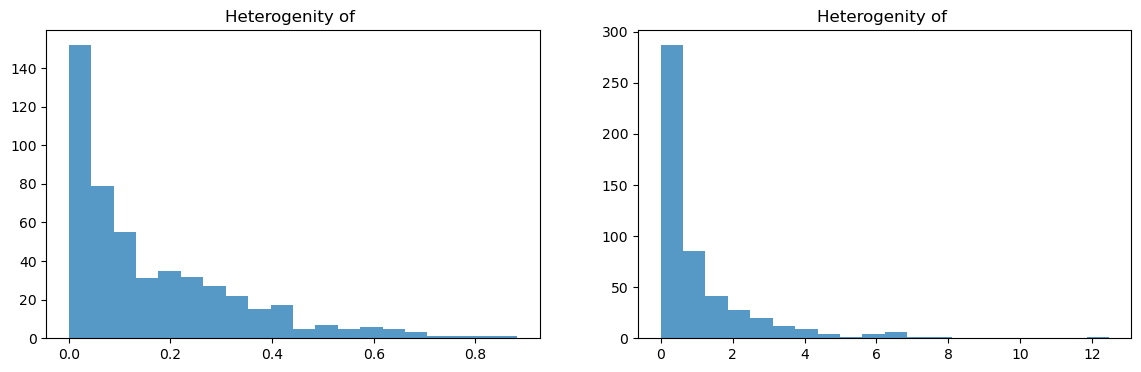

In [99]:
from scipy.stats import gamma, beta
# Plot
gbd = beta.rvs(bg_model.params_['a'], bg_model.params_['b'], size = 500)
ggd = gamma.rvs(bg_model.params_['r'], scale=1./bg_model.params_['alpha'], size = 500)
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.title('Heterogenity of ')
temp = plt.hist(gbd, 20,  alpha=0.75)
plt.subplot(122) 
plt.title('Heterogenity of ')
temp = plt.hist(ggd, 20,  alpha=0.75)
     

In [ ]:

# Customers expected to make the most purchases in 3 months
df['Num_tax_pred'] = bg_model.conditional_expected_number_of_purchases_up_to_time(3*30,
                                                    df['Frequency'],
                                                    df['Recency'],
                                                    df['T'])

print(df.sort_values(by = "predicted_purchases").tail(5))
print()

# plotting the frequency & recency matrix (computes the expected number of transactions a customer is to make in the next time period, given the R(age at last purchase) and F (the number of repeat transactions made))
plt.figure(figsize=(8, 4))
plot_frequency_recency_matrix(bg_model)

# plotting the churn matrix/ probability of active customer
plt.figure(figsize=(8, 4))
plot_probability_alive_matrix(bg_model)
print()


#### **2.2. Pareto - Negative Binomial Distribution + Gamma Gamma Distribution Model**

#### **Reference Work :**

https://readmedium.com/measuring-customers-value-using-python-lifetimes-d8b19a04e9c1